In [ ]:
!pip install yfinance

In [ ]:
!pip install pandas_datareader

1. First, I am going to collect stock data on SPY, TSLA, GM, and RACE. Then I directly load the data to Colab using libraries called “pandas_datareader” and “yfinance”.


2. Write a loop to load these four stock price data. I append the data as one long dataset (use “pd.concat”) call it “df”, and print the first 15 datapoints of “df”.

3. Sort the “df” data by company name and the date from the newest to the oldest. Call this new data “df_sorted” and print the first 15 datapoints of “df_sorted” to make sure that I successfully did the sorting.

4. Make a new dataset named “df_close” that only keep the close price for each stock. Transform “df” from its current long format into a short, wide format. The first column should be the date. The next columns (from the second to the fifth) should be the closing prices for each stock.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yfinance as yf
import requests
import json
from datetime import datetime, timedelta
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
import os
from google.colab import drive
from pandas_datareader.data import DataReader
from datetime import datetime
from pandas_datareader import data as pdr
%matplotlib inline

end = datetime.now()
start = datetime(end.year-1,end.month,end.day)

tech_list=['SPY','TSLA','GM','RACE']

for stock in tech_list:
  globals()[stock]=yf.download(stock,start,end)

company_list=[SPY,TSLA,GM,RACE]
company_name=['SPY','Tesla','GM','Ferrari']

for company, com_name in zip(company_list,company_name):
    company['company_name']=com_name
df=pd.concat(company_list,axis=0)
df.head(15)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,company_name
Date,,,,,,,
2023-10-02,426.619995,428.600006,424.459991,427.309998,421.608795,83798600,SPY
2023-10-03,425.059998,427.369995,420.179993,421.589996,415.965088,103760600,SPY
2023-10-04,422.070007,425.429993,420.559998,424.660004,418.994171,87453000,SPY
2023-10-05,424.359985,425.369995,421.170013,424.500000,418.836273,70142700,SPY
2023-10-06,421.970001,431.130005,420.600006,429.540009,423.809052,113202700,SPY
2023-10-09,427.579987,432.880005,427.010010,432.290009,426.522339,80374400,SPY
2023-10-10,432.940002,437.220001,432.529999,434.540009,428.742310,78607300,SPY
2023-10-11,435.640015,436.579987,433.179993,436.320007,430.498566,62451700,SPY
2023-10-12,436.950012,437.339996,431.230011,433.660004,427.874054,81154200,SPY


#Sort the data

In [ ]:
df_sorted=df.sort_values(by=['company_name','Date'],ascending=True)
df_sorted.head(15)

,Open,High,Low,Close,Adj Close,Volume,company_name
Date,,,,,,,
2023-10-02,295.760010,297.480011,295.005005,296.589996,294.700073,248100,Ferrari
2023-10-03,295.559998,297.238007,293.489990,294.549988,292.673065,234400,Ferrari
2023-10-04,295.829987,299.589996,294.420013,299.589996,297.680939,162000,Ferrari
2023-10-05,300.450012,301.200012,297.075012,299.950012,298.038666,226800,Ferrari
2023-10-06,299.970001,305.410004,297.649994,305.399994,303.453918,257400,Ferrari
2023-10-09,300.019989,301.450012,297.899994,300.510010,298.595093,187700,Ferrari
2023-10-10,307.029999,309.220001,304.549988,305.209991,303.265137,385900,Ferrari
2023-10-11,312.660004,313.059998,307.915009,309.820007,307.845764,353900,Ferrari
2023-10-12,313.059998,313.399994,307.429993,309.070007,307.100555,281900,Ferrari


#Reshape the Data


In [ ]:
df_close=df[['Close','company_name']]
df_close=df_close.pivot(columns='company_name')
df_close.head(15)

Close                                   
company_name     Ferrari         GM         SPY       Tesla
Date                                                       
2023-10-02    296.589996  32.470001  427.309998  251.600006
2023-10-03    294.549988  31.379999  421.589996  246.529999
2023-10-04    299.589996  31.040001  424.660004  261.160004
2023-10-05    299.950012  30.309999  424.500000  260.049988
2023-10-06    305.399994  30.900000  429.540009  260.529999
2023-10-09    300.510010  30.990000  432.290009  259.670013
2023-10-10    305.209991  31.480000  434.540009  263.619995
2023-10-11    309.820007  30.980000  436.320007  262.989990
2023-10-12    309.070007  30.320000  433.660004  258.869995
2023-10-13    312.019989  29.660000  431.500000  251.119995
2023-10-16    315.040009  30.059999  436.040009  253.919998
2023-10-17    309.570007  30.330000  436.019989  254.850006
2023-10-18    303.489990  29.480000  430.209991  242.679993
2023-10-19    301.390015  29.330000  426.429993  220.110001
2023-10-20    301.700012  29.660000  421.190002  211.990005

In [ ]:
summary=df_close.describe()
summary

Close                                    
company_name     Ferrari          GM         SPY       Tesla
count         253.000000  253.000000  253.000000  253.000000
mean          397.106324   40.364862  505.657312  209.497470
std            50.082787    6.626820   42.976676   31.046859
min           294.549988   26.650000  410.679993  142.050003
25%           353.750000   35.439999  473.880005  180.009995
50%           412.519989   42.689999  512.849976  209.139999
75%           424.540009   45.619999  542.739990  237.929993
max           496.790009   49.900002  573.760010  263.619995

In [ ]:
#Calculate the correlation coefficient
correlation = df_close.corr().round(2)
print(correlation)

                     Close                  
company_name       Ferrari    GM   SPY Tesla
      company_name                          
Close Ferrari         1.00  0.87  0.92 -0.27
      GM              0.87  1.00  0.95 -0.32
      SPY             0.92  0.95  1.00 -0.20
      Tesla          -0.27 -0.32 -0.20  1.00


In [ ]:
annual_returns = {}

for stock in df_close.columns:
    start_price = df_close[stock].iloc[0]  # Corrected assignment and indexing
    end_price = df_close[stock].iloc[-1]   # Corrected indexing for the last element
    annual_return = ((end_price - start_price) / start_price) * 100
    formatted_return = f"{annual_return:.2f}%"
    annual_returns[stock] = formatted_return

# Create dataframe for better readability
annual_returns_df = pd.DataFrame(list(annual_returns.items()), columns=['Company', 'Annual Returns'])
annual_returns_df

,Company,Annual Returns
0,"(Close, Ferrari)",54.14%
1,"(Close, GM)",38.04%
2,"(Close, SPY)",33.13%
3,"(Close, Tesla)",-1.03%


#Stock price change over time

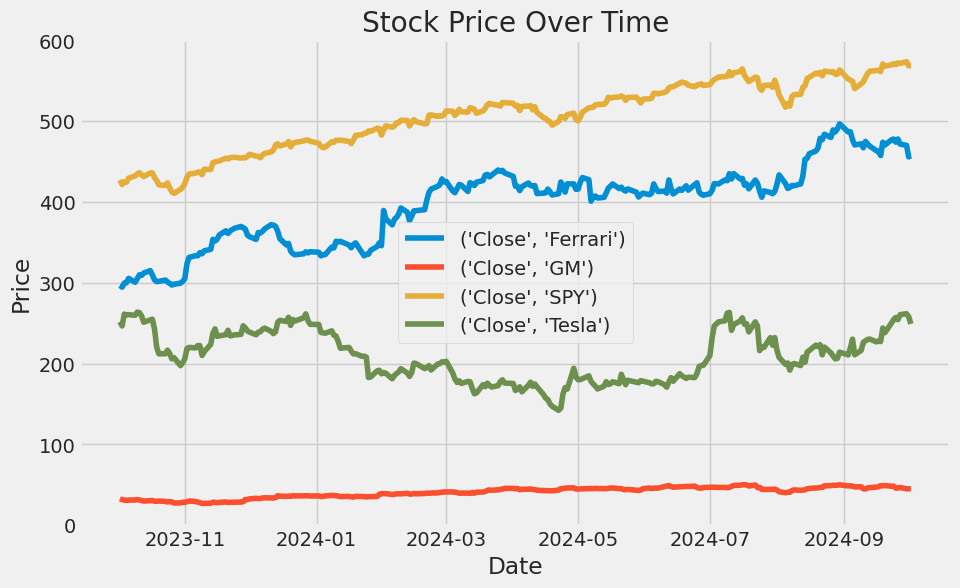

In [ ]:
plt.figure(figsize=(10,6))

for stock in df_close.columns:
  plt.plot(df_close.index,df_close[stock],label=stock)

  plt.title('Stock Price Over Time')
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.legend()

#Stock Price Index by Normalizing the price

In [ ]:
normalized_df_closed = pd.DataFrame()
for stock in df_close.columns:
  first_price = df_close[stock].iloc[0] #Get the first price of the stock
  normalized_price = df_close[stock] / first_price #Normalizing the prices
  normalized_df_closed[stock] = normalized_price*100

normalized_df_closed.head(15)

,"(Close, Ferrari)","(Close, GM)","(Close, SPY)","(Close, Tesla)"
Date,,,,
2023-09-11,100.000000,100.000000,100.000000,100.000000
2023-09-12,98.493459,102.605770,99.451439,97.770314
2023-09-13,98.800712,103.188231,99.567398,99.166606
2023-09-14,99.996703,103.188231,100.425905,100.899197
2023-09-15,99.431743,104.077259,98.867205,100.296085
2023-09-18,99.008854,102.207239,98.925185,96.966157
2023-09-19,98.820534,104.107910,98.720031,97.412096
2023-09-20,100.075991,101.778056,97.812466,95.982897
2023-09-21,96.329462,100.275905,96.195786,93.464438


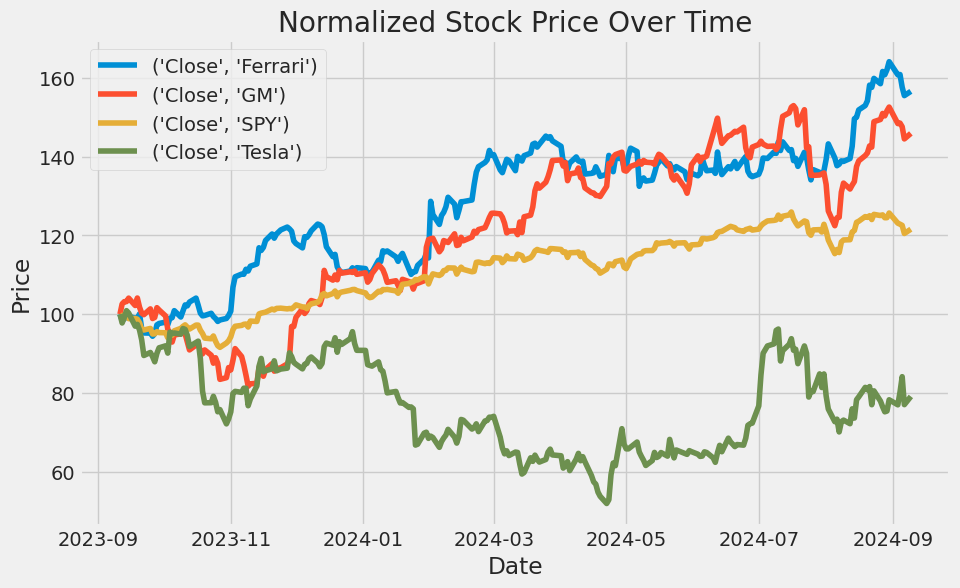

In [ ]:
plt.figure(figsize=(10,6))

for stock in normalized_df_closed.columns:
  plt.plot(normalized_df_closed.index,normalized_df_closed[stock],label=stock)

  plt.title('Normalized Stock Price Over Time')
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.legend()

#B. Daily Return

In [ ]:
daily_returns_df=df_close.pct_change()*100
print(daily_returns_df)

                 Close                              
company_name   Ferrari        GM       SPY     Tesla
Date                                                
2023-09-11         NaN       NaN       NaN       NaN
2023-09-12   -1.506541  2.605770 -0.548561 -2.229686
2023-09-13    0.311952  0.567668  0.116599  1.428135
2023-09-14    1.210509  0.000000  0.862237  1.747151
2023-09-15   -0.564979  0.861559 -1.552090 -0.597737
...                ...       ...       ...       ...
2024-09-03   -2.035068 -2.752107 -2.057901 -1.639342
2024-09-04    0.049318  0.082629 -0.204681  4.183285
2024-09-05   -2.006494 -0.619193 -0.243221  4.904058
2024-09-06   -1.351772 -2.097616 -1.683012 -8.445932
2024-09-09    0.696834  0.974334  0.903103  2.704882

[251 rows x 4 columns]


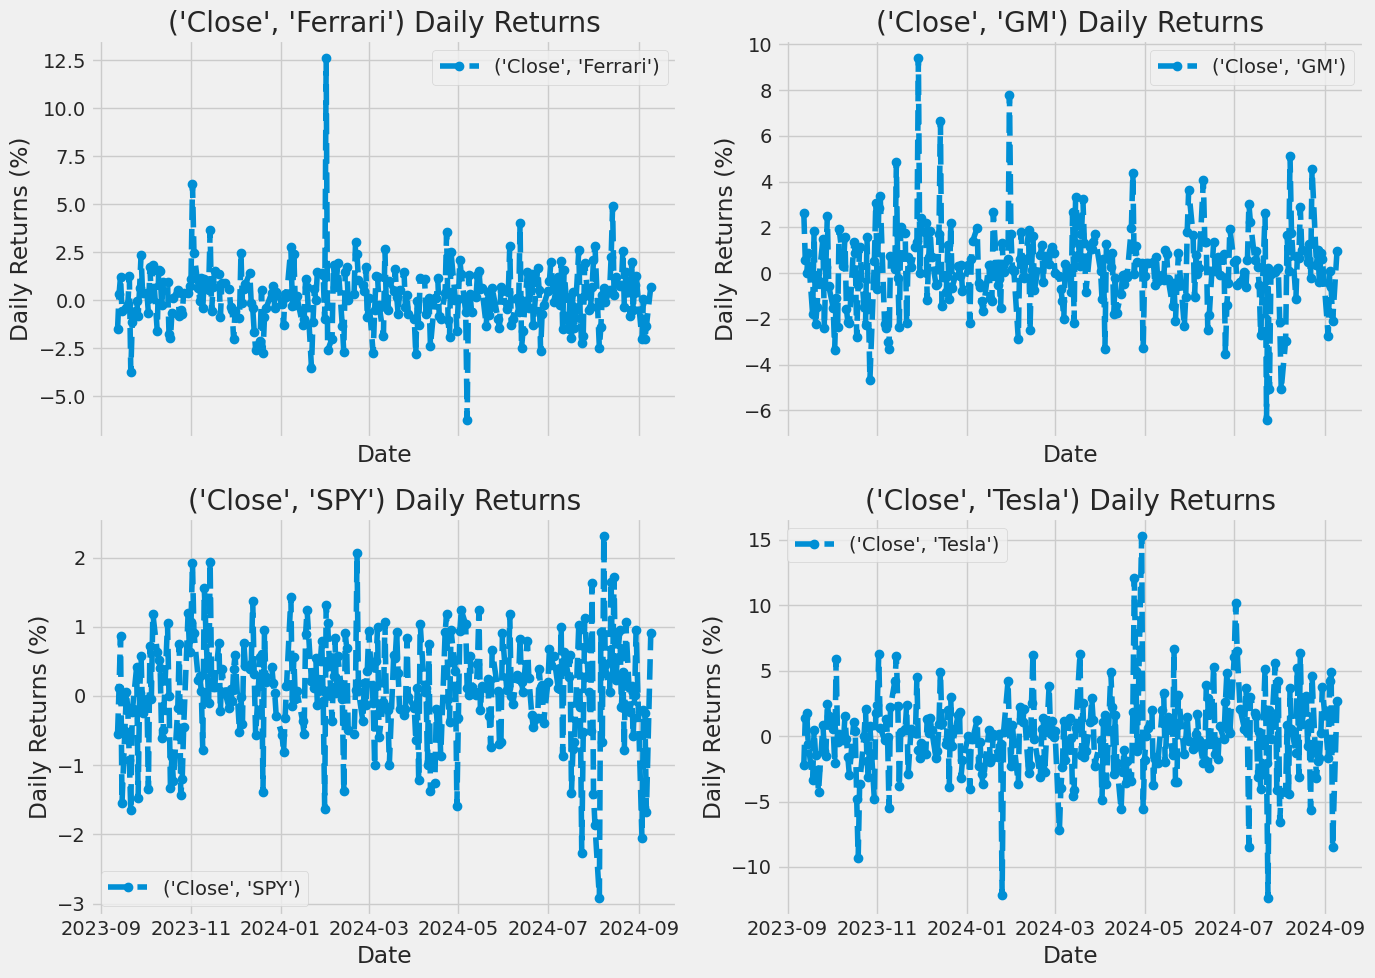

In [ ]:
#Visualize the daily price change
#Create a figure with 4 suplots (2 rows x 2 columns)
fig, axs = plt.subplots(2, 2, figsize=(14,10), sharex=True)

#Plot each stock's daily returns on a separate suplot
stocks = df_close.columns
for i, stock in enumerate(stocks):
  ax = axs[i // 2, i % 2]
  ax.plot(daily_returns_df.index, daily_returns_df[stock],marker='o',linestyle='--',label=stock)
  ax.set_title(f'{stock} Daily Returns')
  ax.set_xlabel('Date')
  ax.set_ylabel('Daily Returns (%)')
  ax.grid(True)
  ax.legend()

#Adjust layout
plt.tight_layout()
plt.show()

#C. Distributions of Daily Returns

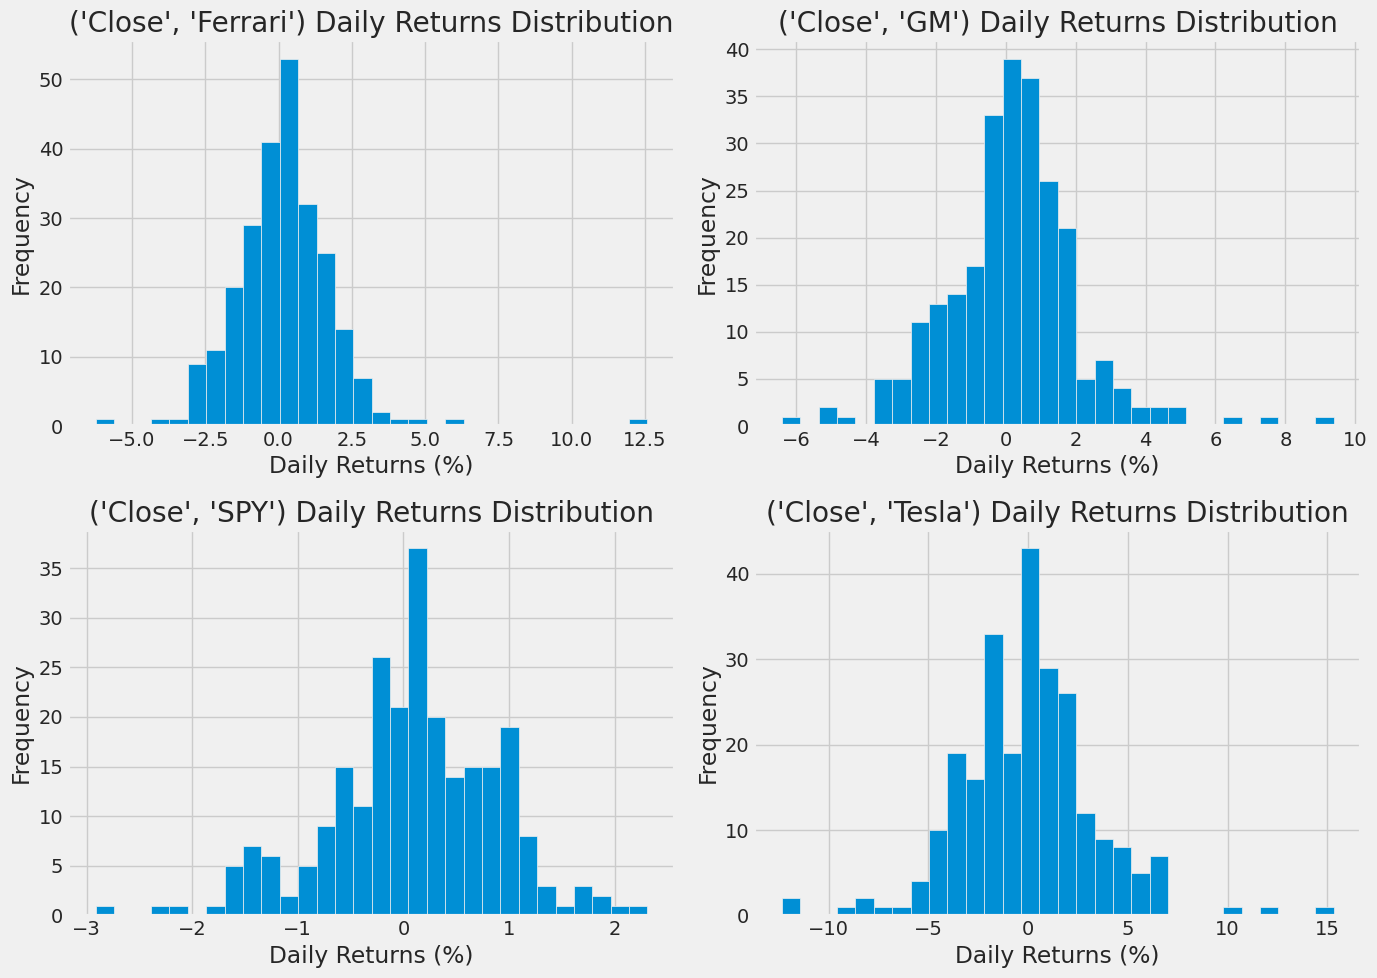

In [ ]:
# Create a figure with 4 suplots (2 rows x 2 columns)
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

# Plot each stock's daily returns distribution on a separate subplot
stocks = df_close.columns
for i, stock in enumerate(stocks):
    ax = axs[i // 2, i % 2]
    ax.hist(daily_returns_df[stock], bins=30)
    ax.set_title(f'{stock} Daily Returns Distribution')
    ax.set_xlabel('Daily Returns (%)')
    ax.set_ylabel('Frequency')
    ax.grid(True)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

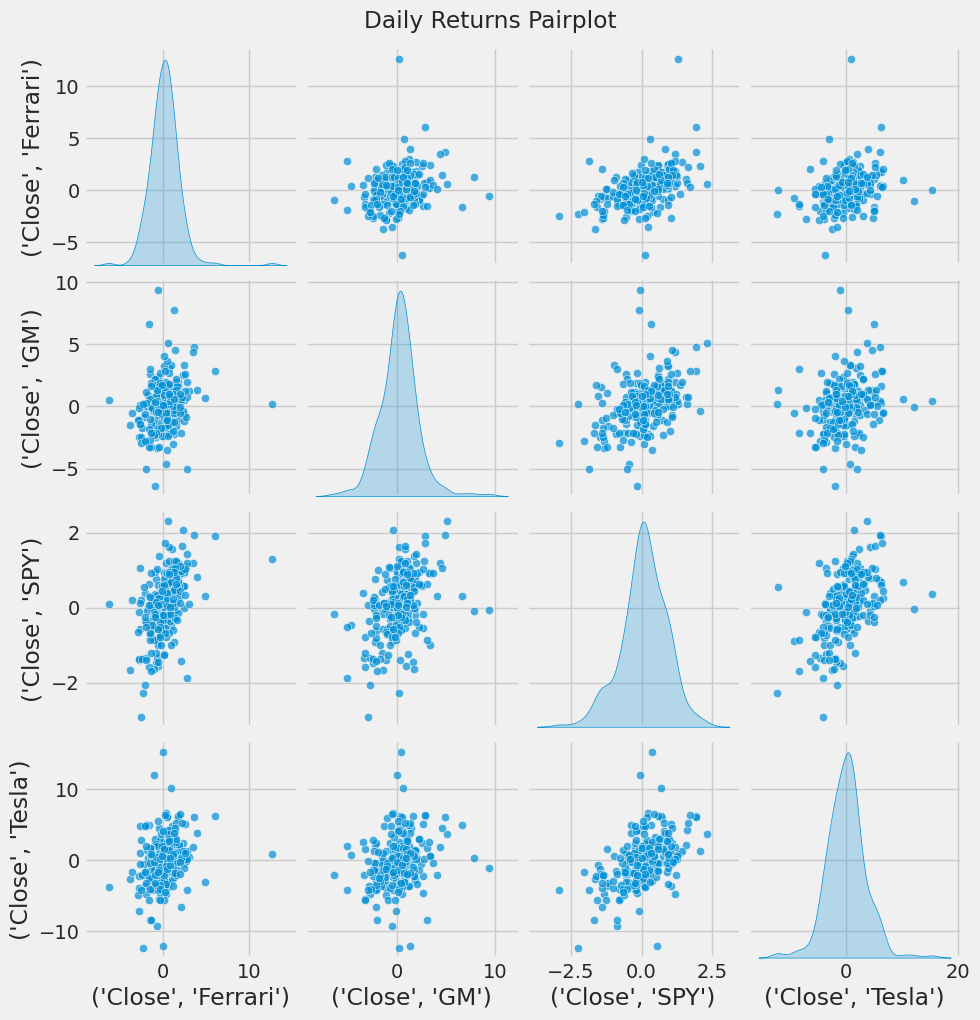

In [ ]:
sns.pairplot(daily_returns_df, diag_kind='kde', plot_kws={
    'alpha': 0.7, 'edgecolor': 'w'
})
plt.suptitle('Daily Returns Pairplot', y=1.02)
plt.show()